# CIA-1 Dataset - Machine Learning Training

This notebook trains ML models on the CIA-1 Predictive Maintenance dataset.

**Dataset**: 500 samples with sensor readings (temperature, speed, torque, vibration, hours)

**Classes**: No Failure, Tool Wear Failure, Overstrain Failure, Power Failure

In [31]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.append(r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes')

from src.data.loaders import CIA1Loader
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
import joblib

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [32]:
# Load dataset
data_dir = r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\CIA-1_Data'
loader = CIA1Loader(data_dir)
X, y, feature_names = loader.load_data()

print(f"\nFeature names: {feature_names}")
print(f"\nData shape: X={X.shape}, y={y.shape}")

Loaded CIA-1 Dataset: 500 samples, 9 features
Class distribution: {0: 467, 1: 19, 2: 8, 3: 6}

Feature names: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Vibration Levels ', 'Operational Hours', 'Type_H', 'Type_L', 'Type_M']

Data shape: X=(500, 9), y=(500,)


## 2. Exploratory Data Analysis

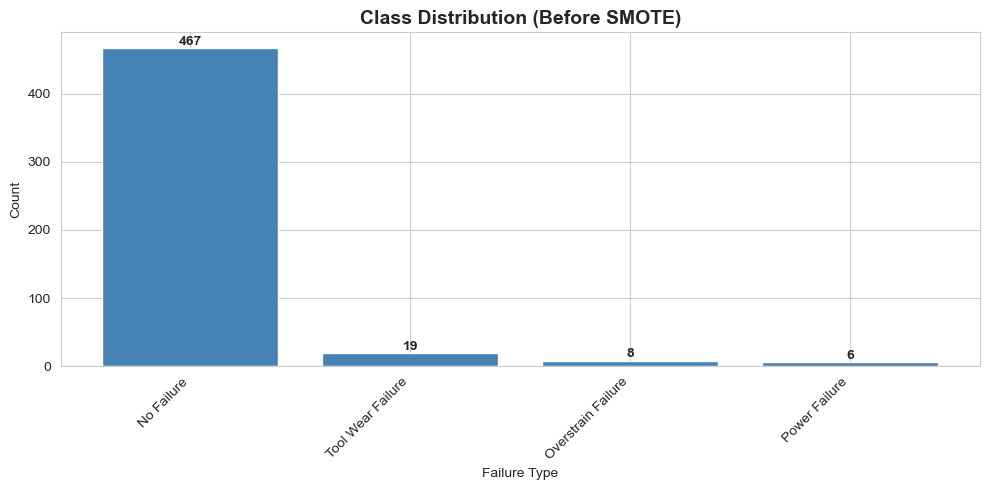

In [33]:
# Class distribution
class_names = loader.get_class_names()
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique], counts, color='steelblue')
plt.title('Class Distribution (Before SMOTE)', fontsize=14, fontweight='bold')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, (cls, count) in enumerate(zip(unique, counts)):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

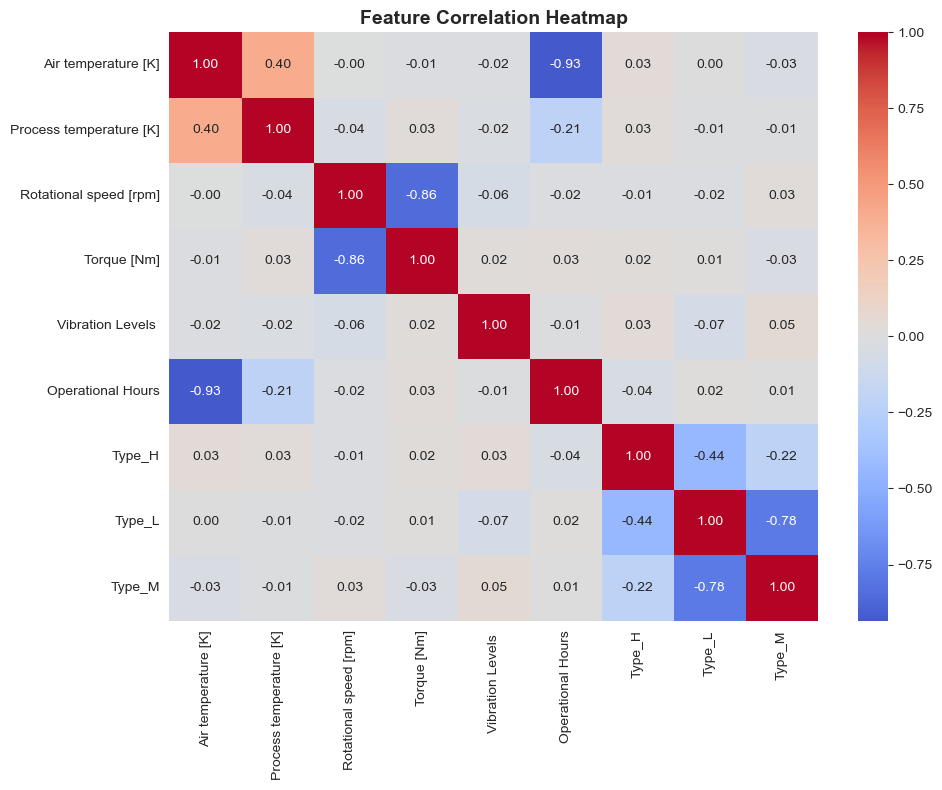

In [34]:
# Feature correlation heatmap
df_features = pd.DataFrame(X, columns=feature_names)
plt.figure(figsize=(10, 8))
sns.heatmap(df_features.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [35]:
# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Train set: (400, 9)
Test set: (100, 9)

Train class distribution: [374  15   6   5]
Test class distribution: [93  4  2  1]


In [36]:
# Apply SMOTE to balance training data
print("\nApplying SMOTE...")
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Balanced train set: {X_train_balanced.shape}")
print(f"Balanced class distribution: {np.bincount(y_train_balanced)}")


Applying SMOTE...
Balanced train set: (1496, 9)
Balanced class distribution: [374 374 374 374]


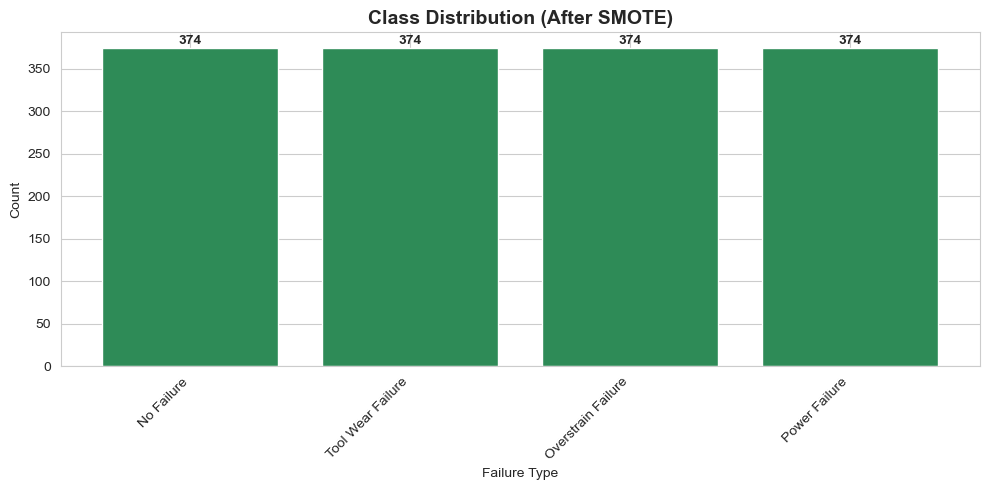

In [37]:
# Visualize class distribution after SMOTE
unique_bal, counts_bal = np.unique(y_train_balanced, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique_bal], counts_bal, color='seagreen')
plt.title('Class Distribution (After SMOTE)', fontsize=14, fontweight='bold')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, (cls, count) in enumerate(zip(unique_bal, counts_bal)):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")

Data scaled successfully.


## 4. Model Training

In [39]:
# Define models and hyperparameter grids
models = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear']
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance']
        }
    }
}

# Train models with GridSearchCV
trained_models = {}
results = []

for name, config in models.items():
    print(f"\nTraining {name}...")
    grid = GridSearchCV(
        config['model'],
        config['params'],
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )
    grid.fit(X_train_scaled, y_train_balanced)
    
    # Store best model
    trained_models[name] = grid.best_estimator_
    
    # Evaluate on test set
    y_pred = grid.predict(X_test_scaled)
    test_acc = np.mean(y_pred == y_test)
    
    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'CV F1 (Macro)': grid.best_score_,
        'Test Accuracy': test_acc
    })
    
    print(f"Best Params: {grid.best_params_}")
    print(f"CV F1 Score: {grid.best_score_:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

# Results summary
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))


Training Random Forest...
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
CV F1 Score: 0.9724
Test Accuracy: 0.8800

Training SVM...
Best Params: {'C': 10, 'kernel': 'rbf'}
CV F1 Score: 0.9470
Test Accuracy: 0.7500

Training Gradient Boosting...
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
CV F1 Score: 0.9751
Test Accuracy: 0.8900

Training KNN...
Best Params: {'n_neighbors': 3, 'weights': 'distance'}
CV F1 Score: 0.9364
Test Accuracy: 0.7600

RESULTS SUMMARY
            Model                                                      Best Params  CV F1 (Macro)  Test Accuracy
    Random Forest {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}       0.972372           0.88
              SVM                                       {'C': 10, 'kernel': 'rbf'}       0.947002           0.75
Gradient Boosting      {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}       0.975143           0.89
              KNN        

## 5. Model Evaluation

In [40]:
# Evaluate best model (highest test accuracy)
best_model_name = results_df.loc[results_df['Test Accuracy'].idxmax(), 'Model']
best_model = trained_models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print("\nClassification Report:")
y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=class_names))


Best Model: Gradient Boosting

Classification Report:
                    precision    recall  f1-score   support

        No Failure       0.94      0.96      0.95        93
 Tool Wear Failure       0.00      0.00      0.00         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.89       100
         macro avg       0.23      0.24      0.24       100
      weighted avg       0.87      0.89      0.88       100



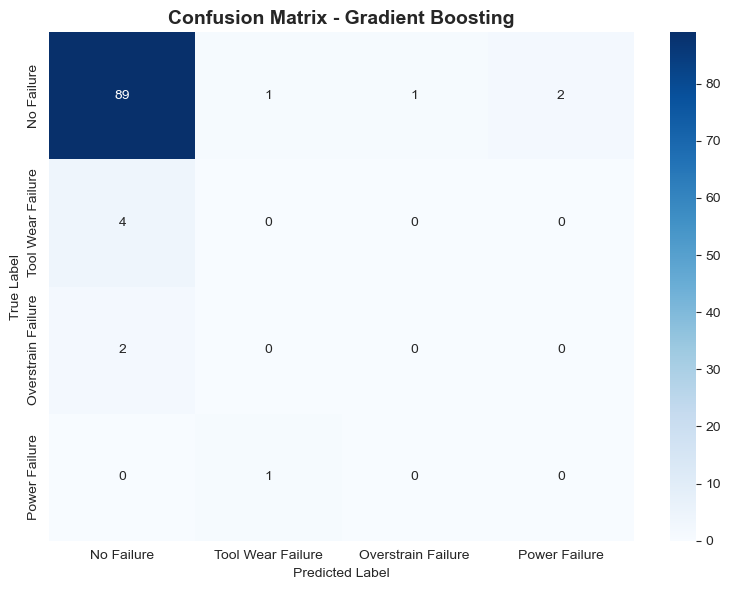

In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

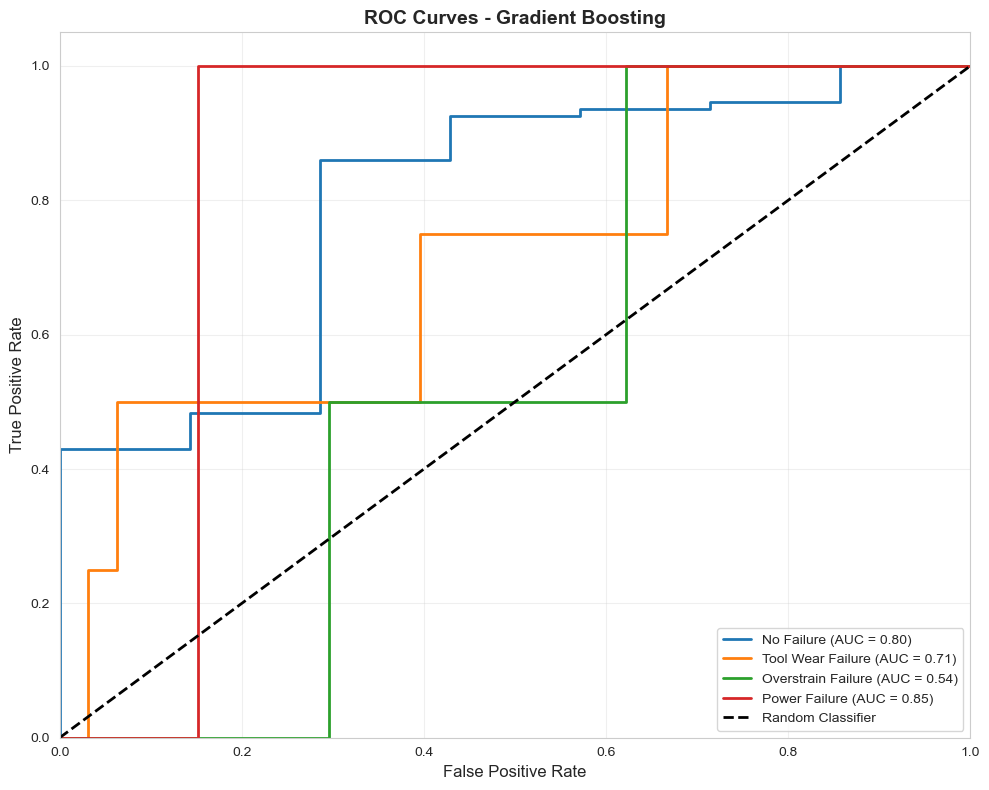

In [42]:
# ROC Curves (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
y_score = best_model.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curves - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

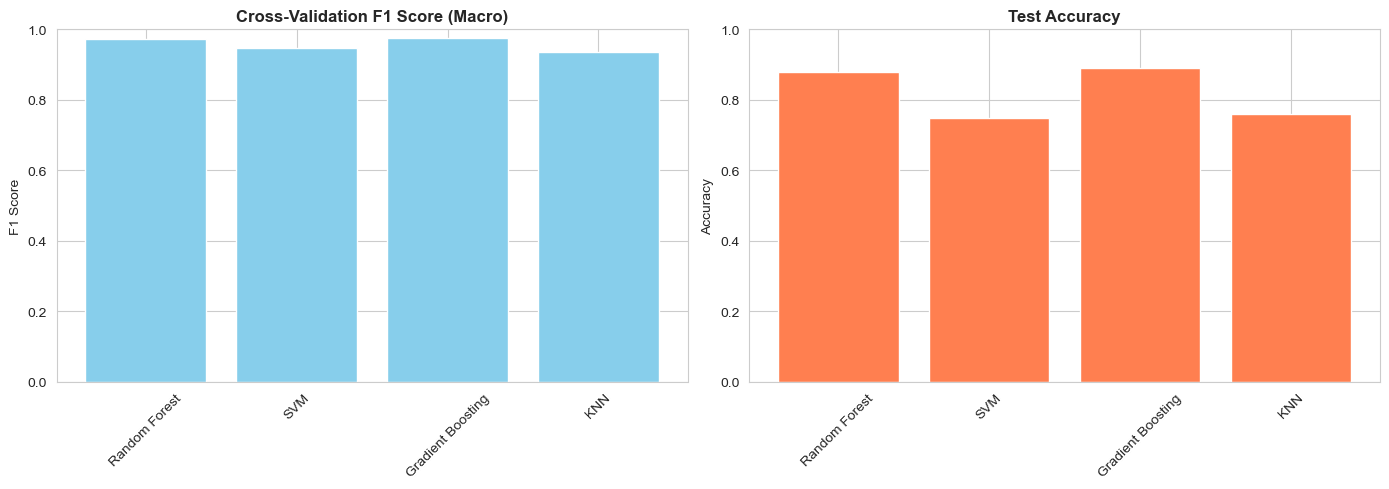

In [43]:
# Model Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV F1 Score
axes[0].bar(results_df['Model'], results_df['CV F1 (Macro)'], color='skyblue')
axes[0].set_title('Cross-Validation F1 Score (Macro)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)

# Test Accuracy
axes[1].bar(results_df['Model'], results_df['Test Accuracy'], color='coral')
axes[1].set_title('Test Accuracy', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Save Models

In [44]:
# Create directory for models
model_dir = r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_ml'
os.makedirs(model_dir, exist_ok=True)

# Save all models
for name, model in trained_models.items():
    filename = os.path.join(model_dir, f"{name.replace(' ', '_').lower()}_model.pkl")
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

# Save scaler
scaler_file = os.path.join(model_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_file)
print(f"Saved: {scaler_file}")

# Save results
results_df.to_csv(os.path.join(model_dir, 'model_comparison.csv'), index=False)
print(f"\nAll models saved to: {model_dir}")

Saved: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_ml\random_forest_model.pkl
Saved: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_ml\svm_model.pkl
Saved: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_ml\gradient_boosting_model.pkl
Saved: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_ml\knn_model.pkl
Saved: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_ml\scaler.pkl

All models saved to: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_ml
